Step 1

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

#testedit

seed = 42
np.random.seed(seed)

print("Imported numpy, pandas, scipy.stats, matplotlib, seaborn")
print("Random seed set to", seed)

Imported numpy, pandas, scipy.stats, matplotlib, seaborn
Random seed set to 42


Step 2

In [ ]:
# Step 2: harder simulation parameters
#
n_patients_group1 = 10
n_patients_group2 = 10
cells_per_patient = 50
n_genes_total = 1000
n_signal_genes = 100

fold_change = 3
mu_background = 2
sigma2 = 0.20
dispersion = 15.0

size_factor_mean = 2000
size_factor_sd = 300

print("Simulation parameters defined")
print("Group 1 patients:", n_patients_group1)
print("Group 2 patients:", n_patients_group2)
print("Cells per patient:", cells_per_patient)
print("Total genes:", n_genes_total)
print("Signal genes:", n_signal_genes)
print("Fold change:", fold_change)

Simulation parameters defined
Group 1 patients: 10
Group 2 patients: 10
Cells per patient: 50
Total genes: 1000
Signal genes: 100
Fold change: 3


Step 3

In [ ]:
# Step 3: create patient metadata

patient_ids = [f"P{i+1}" for i in range(n_patients_group1 + n_patients_group2)]
groups = (
    ["Group1"] * n_patients_group1 +
    ["Group2"] * n_patients_group2
)

patients_df = pd.DataFrame({
    "patient_id": patient_ids,
    "group": groups
})

patients_df

,patient_id,group
0,P1,Group1
1,P2,Group1
2,P3,Group1
3,P4,Group1
4,P5,Group1
5,P6,Group1
6,P7,Group1
7,P8,Group1
8,P9,Group1
9,P10,Group1


Step 4

In [ ]:
# Step 4: create cell metadata with size factors

cell_rows = []

for _, row in patients_df.iterrows():
    patient_id = row["patient_id"]
    group = row["group"]

    size_factors = np.random.normal(loc=size_factor_mean, scale=size_factor_sd, size=cells_per_patient)
    size_factors = np.clip(size_factors, a_min=1, a_max=None)

    for cell_idx in range(cells_per_patient):
        cell_rows.append({
            "patient_id": patient_id,
            "group": group,
            "cell_id": f"{patient_id}_C{cell_idx+1}",
            "size_factor": size_factors[cell_idx]
        })

cells_df = pd.DataFrame(cell_rows)

cells_df.head()

,patient_id,group,cell_id,size_factor
0,P1,Group1,P1_C1,2149.014246
1,P1,Group1,P1_C2,1958.520710
2,P1,Group1,P1_C3,2194.306561
3,P1,Group1,P1_C4,2456.908957
4,P1,Group1,P1_C5,1929.753988


Step 5

In [ ]:
# Step 5: label genes

gene_ids = [f"G{i+1}" for i in range(n_genes_total)]

signal_gene_ids = gene_ids[:n_signal_genes]
background_gene_ids = gene_ids[n_signal_genes:]

genes_df = pd.DataFrame({
    "gene_id": gene_ids,
    "gene_type": ["signal"] * n_signal_genes + ["background"] * (n_genes_total - n_signal_genes)
})

genes_df.head(10)

,gene_id,gene_type
0,G1,signal
1,G2,signal
2,G3,signal
3,G4,signal
4,G5,signal
5,G6,signal
6,G7,signal
7,G8,signal
8,G9,signal
9,G10,signal


Step 6

In [ ]:
# Step 6: patient random effects

patient_effects = np.random.normal(
    loc=0,
    scale=np.sqrt(sigma2),
    size=len(patients_df)
)

patients_df["gamma_i"] = patient_effects

patients_df

,patient_id,group,gamma_i
0,P1,Group1,0.625811
1,P2,Group1,0.413509
2,P3,Group1,0.026668
3,P4,Group1,-0.289319
4,P5,Group1,0.312255
5,P6,Group1,0.175972
6,P7,Group1,0.400343
7,P8,Group1,0.284057
8,P9,Group1,0.469374
9,P10,Group1,-0.239364


Step 7

In [ ]:
# Step 7: define group-specific means

mu_group1_signal = mu_background * fold_change
mu_group2_signal = mu_background

mu_group1_background = mu_background
mu_group2_background = mu_background

print("mu_group1_signal =", mu_group1_signal)
print("mu_group2_signal =", mu_group2_signal)
print("mu_group1_background =", mu_group1_background)
print("mu_group2_background =", mu_group2_background)

mu_group1_signal = 6
mu_group2_signal = 2
mu_group1_background = 2
mu_group2_background = 2


Step 8

In [ ]:
# Step 8: simulate gene expression counts (cleaner NB parameterization)

from scipy.stats import nbinom

count_rows = []

for _, cell in cells_df.iterrows():
    patient_id = cell["patient_id"]
    group = cell["group"]
    cell_id = cell["cell_id"]
    size_factor = cell["size_factor"]
    gamma_i = patients_df.loc[patients_df["patient_id"] == patient_id, "gamma_i"].values[0]

    if group == "Group1":
        signal_mu_base = mu_group1_signal
        background_mu_base = mu_group1_background
    else:
        signal_mu_base = mu_group2_signal
        background_mu_base = mu_group2_background

    signal_mu = signal_mu_base + gamma_i
    background_mu = background_mu_base #can try to remove, easier if you remove if sigma
# make sure std dev is lesser than the mu (gamma i shouldnt be too big), can set mu to 2 and
# keep gamma i 0.4,
    for gene_id in signal_gene_ids:
        mu = size_factor * signal_mu
        var = mu + (mu**2) / dispersion #you can try increasing this because mu is 4000-16000
        p = mu / var
        n = mu * p / (1 - p)
        expr = nbinom.rvs(n, p)

        count_rows.append({
            "patient_id": patient_id,
            "group": group,
            "cell_id": cell_id,
            "gene_id": gene_id,
            "gene_type": "signal",
            "expression": expr
        })
# check for correlation with spearmann or pearson coefficient
    for gene_id in background_gene_ids:
        mu = size_factor * background_mu
        var = mu + (mu**2) / dispersion
        p = mu / var
        n = mu * p / (1 - p)
        expr = nbinom.rvs(n, p)

        count_rows.append({
            "patient_id": patient_id,
            "group": group,
            "cell_id": cell_id,
            "gene_id": gene_id,
            "gene_type": "background",
            "expression": expr
        })

counts_df = pd.DataFrame(count_rows)
counts_df.head()

,patient_id,group,cell_id,gene_id,gene_type,expression
0,P1,Group1,P1_C1,G1,signal,15910
1,P1,Group1,P1_C1,G2,signal,11835
2,P1,Group1,P1_C1,G3,signal,13085
3,P1,Group1,P1_C1,G4,signal,8653
4,P1,Group1,P1_C1,G5,signal,14836


Step 9

In [ ]:
# Step 9: reshape to gene x cell matrix

expression_matrix = counts_df.pivot_table(
    index="gene_id",
    columns="cell_id",
    values="expression",
    aggfunc="sum"
)
#new los min Loss contrastive (from Jessica's paper) + lambda sum of stochastic gate values
expression_matrix

cell_id,P10_C1,P10_C10,P10_C11,P10_C12,P10_C13,P10_C14,P10_C15,P10_C16,P10_C17,P10_C18,...,P9_C46,P9_C47,P9_C48,P9_C49,P9_C5,P9_C50,P9_C6,P9_C7,P9_C8,P9_C9
gene_id,,,,,,,,,,,,,,,,,,,,,
G1,10576,9389,14268,9935,11886,13101,7312,15352,12734,12337,...,11951,21034,17737,14090,11744,8157,17697,11221,11679,11182
G10,7639,12163,11622,11817,7217,11732,13667,11225,14766,11801,...,21905,17470,11741,11044,8407,11496,16326,13331,10524,16178
G100,18397,8559,13639,13012,8555,12140,9171,11434,12129,11825,...,15801,16402,11185,9188,15767,8686,14933,13564,12499,12531
G1000,4662,2202,5113,3338,2889,6199,4120,3143,3499,3338,...,6587,3404,2992,4897,5252,3602,2701,3631,4411,2460
G101,3961,3265,5296,4704,3649,4304,3028,4774,2375,2963,...,3487,3623,2565,6392,3672,4083,3427,3164,2148,5613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
G995,4063,2747,4768,3836,3700,7129,3794,3140,4018,4038,...,4462,4571,3385,4673,3462,1636,5216,2335,4514,2092
G996,4140,2579,4527,3993,4303,4764,5288,3720,3275,6711,...,3320,2228,3578,3970,3463,2625,6420,3298,2503,2532
G997,5553,4152,6480,4016,4609,2273,3358,2495,4845,5321,...,5019,3733,3481,2707,3245,2438,4599,2510,3005,4736


Step 10

In [ ]:
# Step 10: basic validation summaries

summary_by_gene = counts_df.groupby(["gene_id", "gene_type"])["expression"].agg(
    ["mean", "median", "std", "min", "max"]
).reset_index()

summary_by_gene.head(10)

,gene_id,gene_type,mean,median,std,min,max
0,G1,signal,8475.196,7314.5,4925.196862,1049,27412
1,G10,signal,8424.816,7147.0,5057.340776,1509,26351
2,G100,signal,8438.164,7229.5,5012.792426,1398,24486
3,G1000,background,3962.387,3814.5,1204.248127,1525,10302
4,G101,background,4015.663,3850.0,1230.895841,1437,8725
5,G102,background,4004.496,3910.5,1182.835590,1180,8582
6,G103,background,4005.719,3833.5,1251.099204,1289,8934
7,G104,background,3990.098,3850.5,1206.722666,1261,10335
8,G105,background,4020.980,3881.0,1194.177539,1444,9064
9,G106,background,4052.811,3903.0,1219.408869,1210,9934


Step 11

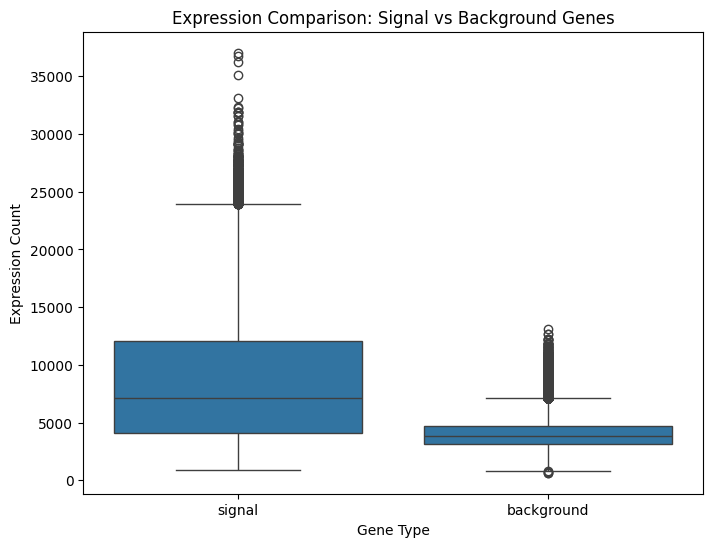

In [ ]:
# Step 11: box plot for signal vs background gene expression

plot_df = counts_df.copy()

plt.figure(figsize=(8, 6))
sns.boxplot(data=plot_df, x="gene_type", y="expression")
plt.title("Expression Comparison: Signal vs Background Genes")
plt.xlabel("Gene Type")
plt.ylabel("Expression Count")
plt.show()

Step 12

# L1 Gating Test

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import GroupShuffleSplit

# scikit-learn >=1.8 emits a FutureWarning about the penalty= param being
# deprecated in favor of l1_ratio=; harmless here (we're pinned to
# penalty="l1"/solver="saga"), suppressed so it doesn't clutter the report.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

In [ ]:
# Build cell-level matrix
X_df = counts_df.pivot_table(
    index="cell_id",
    columns="gene_id",
    values="expression",
    aggfunc="sum",
    fill_value=0
)

cell_labels = cells_df[["cell_id", "group"]].drop_duplicates().set_index("cell_id").loc[X_df.index]
y = (cell_labels["group"] == "Group2").astype(int).values

gene_types = genes_df.set_index("gene_id").loc[X_df.columns, "gene_type"]

In [ ]:
# Split and train L1 model
# X_train, X_test, y_train, y_test = train_test_split(
#     X_df.values, y, test_size=0.2, random_state=42, stratify=y
# )

groups_arr = cell_labels.index.map(lambda c: c.split("_")[0]).values  # patient_id per cell
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_df.values, y, groups=groups_arr))

X_train, X_test = X_df.values[train_idx], X_df.values[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

#cross validation for lambda tuning, define loss function
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=0.05,  #C=1/Lambda. Low C- strong regularization, high C- weak regularization
    max_iter=5000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Train accuracy: 0.9975
Test accuracy: 0.99


In [ ]:
# Extract gene scores
coef = model.coef_[0]

feature_scores = pd.DataFrame({
    "gene_id": X_df.columns,
    "gene_type": gene_types.values,
    "coef": coef,
    "abs_coef": np.abs(coef)
})

feature_scores.head()

,gene_id,gene_type,coef,abs_coef
0,G1,signal,0.0,0.0
1,G10,signal,0.0,0.0
2,G100,signal,0.0,0.0
3,G1000,background,0.0,0.0
4,G101,background,0.0,0.0


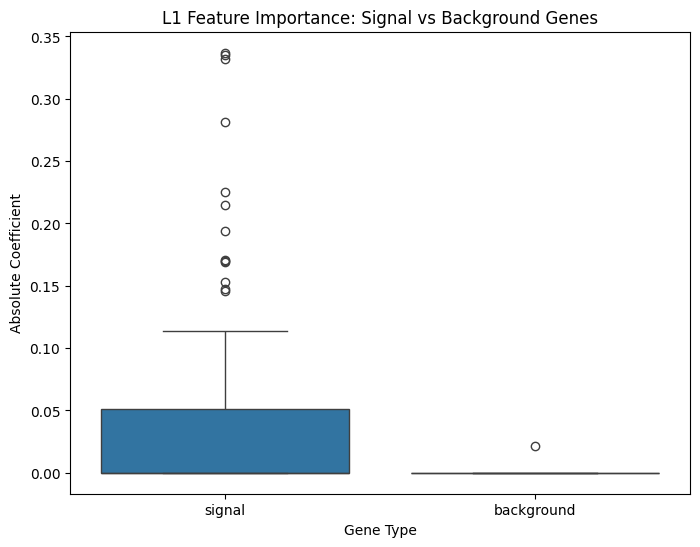

In [ ]:
# Compare signal vs. background
plt.figure(figsize=(8, 6))
sns.boxplot(data=feature_scores, x="gene_type", y="abs_coef")
plt.title("L1 Feature Importance: Signal vs Background Genes")
plt.xlabel("Gene Type")
plt.ylabel("Absolute Coefficient")
plt.show()

In [ ]:
# Long format (one row per cell-gene pair) — good for records/reproducibility
#counts_df.to_csv("counts_long.csv", index=False)

# Wide format (genes as rows, cells as columns) — good for feeding into a model
#expression_matrix.to_csv("expression_matrix.csv")

# Gene answer key (which genes are signal vs background)
#genes_df.to_csv("genes_labels.csv", index=False)

# Patient metadata (group, gamma_i)
#patients_df.to_csv("patients.csv", index=False)

# STG (Stochastic Gates) Baseline

Applies the **Stochastic Gates (STG)** feature selection method from
Yamada, Lindenbaum, Negahban & Kluger, *"Feature Selection using Stochastic
Gates"* (ICML 2020) -- the "standard stochastic gating" baseline referenced
throughout the thesis methodology (step 3). Each input feature (gene) gets
a learnable stochastic gate, trained jointly with an MLP classifier via
gradient descent; gates for uninformative features are pushed toward 0
(closed) and informative ones toward 1 (open).

- Project page: https://yutaroyamada.com/stg/
- Official implementation: https://github.com/runopti/stg

This notebook has **no correlated gene modules** -- signal genes are one
flat, independent group (see `correlated_syntheticdata.ipynb` for the
module version). So there's no per-module recovery question here; the
question is simpler: does STG open gates on (most of) the 100 signal genes
while keeping the 900 background genes closed, same as the existing L1
Gating Test above?

Step 13: install and import STG

In [ ]:
# Step 13: install and import STG
#
# pip install stg  (uncomment the line below if not already installed in
# this environment -- e.g. the first time this notebook runs on Colab)
# !pip install stg

# The `stg` package (last released a while ago) still references
# collections.Sequence/Mapping/Iterable/Set, which were removed from the
# `collections` module in Python 3.10+ (they now live in collections.abc
# only). This shim restores the old aliases so `stg` imports cleanly on
# modern Python -- harmless, does not affect behavior.
import collections
import collections.abc
for _name in ("Iterable", "Mapping", "Sequence", "Set", "MutableMapping",
              "MutableSequence", "MutableSet", "Callable", "Hashable",
              "Sized", "Container"):
    if not hasattr(collections, _name):
        setattr(collections, _name, getattr(collections.abc, _name))

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch")

import torch
from stg import STG

# STG's `random_state` constructor argument is accepted but never actually
# used internally (checked the installed package source) -- it relies on
# the global PyTorch/NumPy RNG state instead. Seed both explicitly right
# before building/training the model (next cell) for reproducibility.

print("STG imported successfully")

STG imported successfully


Step 13b: train STG on the same train/test split as L1

In [ ]:
# Step 13b: train STG on the same train/test split as L1
#
# Reuses X_train_scaled / X_test_scaled / y_train / y_test from the L1
# section above (same GroupShuffleSplit-by-patient split, same
# StandardScaler fit on train only) so the two baselines are directly
# comparable. valid_X/valid_y is used only to print a monitoring loss
# during training (no early stopping here), never to update gradients.
#
# lam is STG's sparsity knob (like L1's C, but inverted: higher lam -> more
# closed gates -> sparser). As with the correlated-modules notebook, STG's
# continuous soft gating feeding a nonlinear MLP tends to keep accuracy
# near-ceiling across a wide lam range rather than trading accuracy for
# sparsity the way L1's convex penalty does -- lam here is chosen for a
# clean, illustrative gate pattern, not to match L1's accuracy.
torch.manual_seed(42)
np.random.seed(42)

stg_lam = 0.5

stg_model = STG(
    task_type="classification",
    input_dim=X_train_scaled.shape[1],
    output_dim=2,
    hidden_dims=[128, 32],
    activation="tanh",
    optimizer="Adam",
    learning_rate=0.01,
    batch_size=X_train_scaled.shape[0],
    feature_selection=True,
    sigma=0.5,
    lam=stg_lam,
    random_state=42,
    device="cpu",
)

stg_model.fit(
    X_train_scaled, y_train.astype(float),
    nr_epochs=200,
    valid_X=X_test_scaled, valid_y=y_test.astype(float),
    print_interval=50,
)

# evaluate() only prints a summary and returns None, so compute accuracy
# directly from predict() instead.
stg_train_acc = (stg_model.predict(X_train_scaled) == y_train).mean()
stg_test_acc = (stg_model.predict(X_test_scaled) == y_test).mean()
print("\nSTG train accuracy:", stg_train_acc)
print("STG test accuracy:", stg_test_acc)

Epoch: 50: loss=0.356569 valid_loss=0.000197
Epoch: 100: loss=0.313646 valid_loss=0.000485
Epoch: 150: loss=0.302901 valid_loss=0.000958
Epoch: 200: loss=0.290089 valid_loss=0.000912

STG train accuracy: 0.99875
STG test accuracy: 1.0


Step 13c: extract gate values

In [ ]:
# Step 13c: extract gate values
#
# get_gates(mode="prob") returns each feature's gate-open probability in
# [0, 1] -- the STG analog of L1's |coefficient|.

gate_probs = stg_model.get_gates(mode="prob")

gate_scores = pd.DataFrame({
    "gene_id": X_df.columns,
    "gene_type": gene_types.values,
    "gate_prob": gate_probs
})

gate_scores.sort_values("gate_prob", ascending=False).head(10)

,gene_id,gene_type,gate_prob
468,G52,signal,0.593680
446,G50,signal,0.583120
856,G87,signal,0.580836
823,G84,signal,0.563840
945,G95,signal,0.559752
679,G71,signal,0.554462
612,G65,signal,0.553151
113,G20,signal,0.541103
557,G60,signal,0.540996
668,G70,signal,0.535224


Step 13d: does STG open signal genes and keep background closed?

Signal genes open:     16 / 100 (16.0%)
Background genes open: 0 / 900 (0.0%)


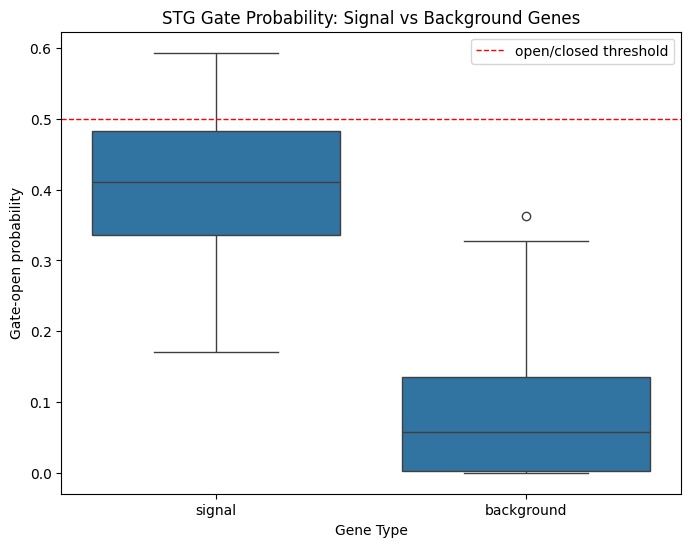

In [ ]:
# Step 13d: signal vs background recovery rate for STG
#
# A gate is treated as "open" if its probability > 0.5 (standard STG
# convention). Directly comparable to the L1 signal-vs-background boxplot
# above (cell "Compare signal vs. background").

STG_GATE_THRESHOLD = 0.5

n_signal_open = (gate_scores.loc[gate_scores["gene_type"] == "signal", "gate_prob"] > STG_GATE_THRESHOLD).sum()
n_background_open = (gate_scores.loc[gate_scores["gene_type"] == "background", "gate_prob"] > STG_GATE_THRESHOLD).sum()
n_signal_total = (gate_scores["gene_type"] == "signal").sum()
n_background_total = (gate_scores["gene_type"] == "background").sum()

print(f"Signal genes open:     {n_signal_open} / {n_signal_total} ({n_signal_open / n_signal_total:.1%})")
print(f"Background genes open: {n_background_open} / {n_background_total} ({n_background_open / n_background_total:.1%})")

plt.figure(figsize=(8, 6))
sns.boxplot(data=gate_scores, x="gene_type", y="gate_prob")
plt.axhline(STG_GATE_THRESHOLD, color="red", linestyle="--", linewidth=1, label="open/closed threshold")
plt.title("STG Gate Probability: Signal vs Background Genes")
plt.xlabel("Gene Type")
plt.ylabel("Gate-open probability")
plt.legend()
plt.show()

Step 13e: L1 vs STG, side by side

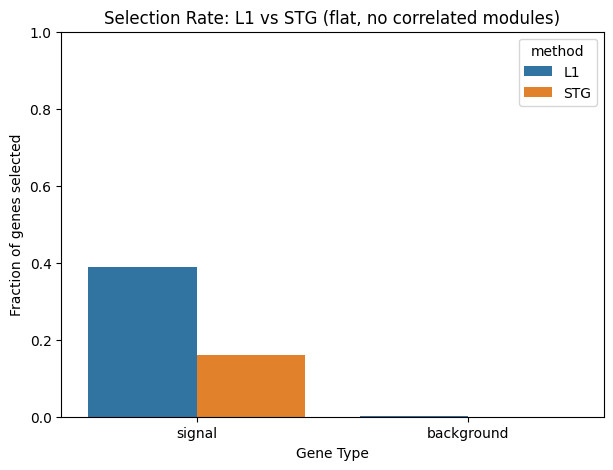

method,L1,STG
gene_type,,
background,0.001111,0.00
signal,0.390000,0.16


In [ ]:
# Step 13e: L1 vs STG, side by side
#
# Fraction of signal genes selected by each method (nonzero L1 coefficient
# vs STG gate_prob > 0.5), and fraction of background genes each method
# mistakenly selects.

l1_signal_rate = (feature_scores.loc[feature_scores["gene_type"] == "signal", "coef"] != 0).mean()
l1_background_rate = (feature_scores.loc[feature_scores["gene_type"] == "background", "coef"] != 0).mean()
stg_signal_rate = n_signal_open / n_signal_total
stg_background_rate = n_background_open / n_background_total

compare_df = pd.DataFrame({
    "method": ["L1", "L1", "STG", "STG"],
    "gene_type": ["signal", "background", "signal", "background"],
    "selection_rate": [l1_signal_rate, l1_background_rate, stg_signal_rate, stg_background_rate]
})

plt.figure(figsize=(7, 5))
sns.barplot(data=compare_df, x="gene_type", y="selection_rate", hue="method")
plt.title("Selection Rate: L1 vs STG (flat, no correlated modules)")
plt.xlabel("Gene Type")
plt.ylabel("Fraction of genes selected")
plt.ylim(0, 1)
plt.show()

compare_df.pivot(index="gene_type", columns="method", values="selection_rate")

Step 13f: summary report (L1 + STG)

In [ ]:
# Step 13f: summary report (L1 + STG)

summary_report = pd.DataFrame({
    "metric": [
        "L1 test accuracy", "L1 train accuracy", "L1 regularization C",
        "L1 signal genes selected", "L1 background genes selected",
        "STG test accuracy", "STG train accuracy", "STG lambda (sparsity)",
        "STG signal genes selected", "STG background genes selected",
    ],
    "value": [
        round(test_acc, 4),
        round(train_acc, 4),
        model.C,
        f"{(feature_scores.loc[feature_scores['gene_type']=='signal','coef']!=0).sum()} / {n_signal_total}",
        f"{(feature_scores.loc[feature_scores['gene_type']=='background','coef']!=0).sum()} / {n_background_total}",
        round(float(stg_test_acc), 4),
        round(float(stg_train_acc), 4),
        stg_lam,
        f"{n_signal_open} / {n_signal_total}",
        f"{n_background_open} / {n_background_total}",
    ]
})
summary_report

,metric,value
0,L1 test accuracy,0.99
1,L1 train accuracy,0.9975
2,L1 regularization C,0.05
3,L1 signal genes selected,39 / 100
4,L1 background genes selected,1 / 900
5,STG test accuracy,1.0
6,STG train accuracy,0.9988
7,STG lambda (sparsity),0.5
8,STG signal genes selected,16 / 100
9,STG background genes selected,0 / 900
